In [2]:
import pandas as pd 

user_reviews_file = ["Data/All_Beauty_UserReview.jsonl", "Data/Appliances.jsonl", "Data/Digital_Music.jsonl"]
products_file = ["Data/meta_All_Beauty.jsonl", "Data/meta_Appliances.jsonl", "Data/meta_Digital_Music.jsonl"]

df_reviews_all = pd.DataFrame()
for i in range(len(user_reviews_file)):
    df_reviews = pd.read_json(user_reviews_file[i], lines=True)
    df_reviews_all = pd.concat([df_reviews_all, df_reviews], ignore_index=True)

df_top30k = pd.read_excel("Data/top30k.xlsx")
df_top30_user = df_reviews_all[df_reviews_all['parent_asin'].isin(df_top30k['parent_asin'])]

In [21]:
df_top30_user['verified_purchase'].value_counts()

verified_purchase
True     58474
False    17026
Name: count, dtype: int64

In [5]:
df_top30_user.to_excel("Data/top30k_user.xlsx")

In [9]:
df = df_top30k.merge(df_top30_user, on='parent_asin', how='inner')
df.shape

(75500, 29)

In [7]:
df_top30k.shape

(29999, 20)

In [8]:
df_top30_user.shape

(75500, 10)

In [18]:
df_top30_user.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [20]:
df_top30_user['verified_purchase'].values

array([ True,  True, False, ...,  True,  True,  True])

In [10]:
df.columns

Index(['main_category', 'title_x', 'average_rating', 'rating_number',
       'features', 'description', 'price', 'images_x', 'videos', 'store',
       'categories', 'details', 'parent_asin', 'bought_together',
       'purchase_score', 'data', 'subtitle', 'author', 'image_path', 'caption',
       'rating', 'title_y', 'text', 'images_y', 'asin', 'user_id', 'timestamp',
       'helpful_vote', 'verified_purchase'],
      dtype='object')

In [17]:
df_top30k.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'purchase_score', 'data',
       'subtitle', 'author', 'image_path', 'caption'],
      dtype='object')

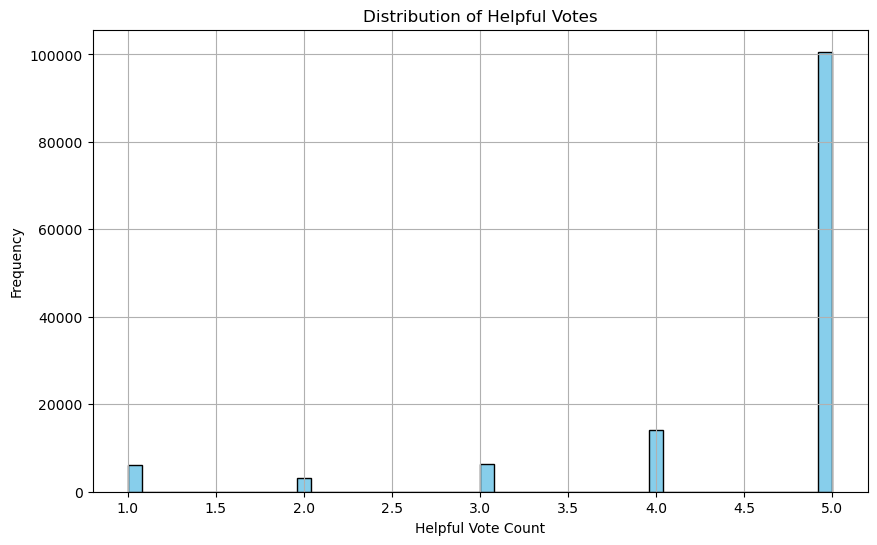

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_reviews['rating'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Helpful Votes')
plt.xlabel('Helpful Vote Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

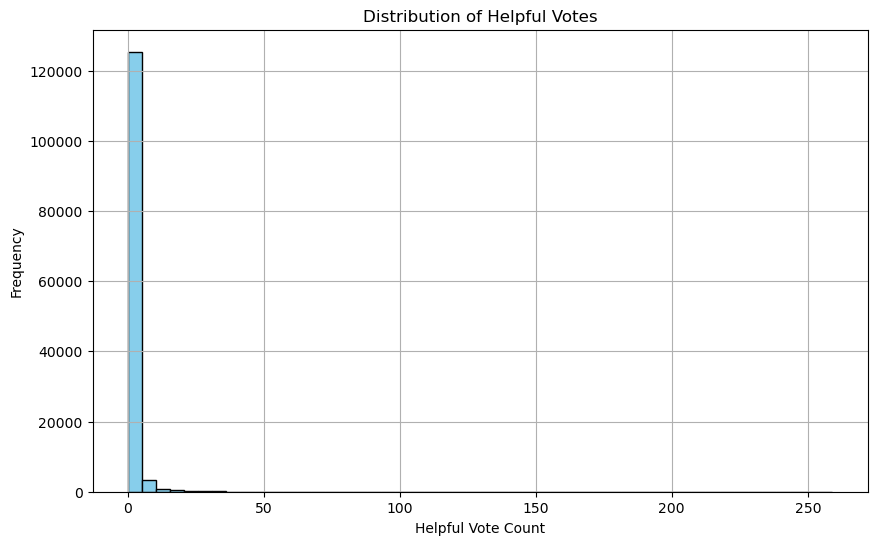

In [15]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_reviews['helpful_vote'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Helpful Votes')
plt.xlabel('Helpful Vote Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
